In [ ]:
!pip install -q xgboost lightgbm catboost shap optuna imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.1 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import gc
import zipfile
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap
import joblib

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ieee-fraud-detection.zip to ieee-fraud-detection (3).zip


In [ ]:
zip_path="ieee-fraud-detection.zip"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
def reduce_memory(df):

    start=df.memory_usage().sum()/1024**2

    print("Memory Before :",round(start,2),"MB")

    for col in df.columns:

        col_type=df[col].dtype

        if col_type!='object':

            cmin=df[col].min()
            cmax=df[col].max()

            if str(col_type)[:3]=='int':

                if cmin>-128 and cmax<127:
                    df[col]=df[col].astype(np.int8)

                elif cmin>-32768 and cmax<32767:
                    df[col]=df[col].astype(np.int16)

                elif cmin>-2147483648 and cmax<2147483647:
                    df[col]=df[col].astype(np.int32)

            else:

                df[col]=df[col].astype(np.float32)

    end=df.memory_usage().sum()/1024**2

    print("Memory After :",round(end,2),"MB")

    return df

In [ ]:
train_transaction=pd.read_csv(
    "dataset/train_transaction.csv",
    nrows=100000
)

train_identity=pd.read_csv(
    "dataset/train_identity.csv",
    nrows=100000
)

In [ ]:
train_transaction=reduce_memory(train_transaction)

train_identity=reduce_memory(train_identity)

Memory Before : 300.6 MB
Memory After : 155.16 MB
Memory Before : 31.28 MB
Memory After : 22.13 MB


In [ ]:
train=train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

print(train.shape)

(100000, 434)


In [ ]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float32(399), int16(1), int32(2), int8(1), object(31)
memory usage: 176.9+ MB


In [ ]:
missing=train.isnull().mean()*100

missing=missing.sort_values(ascending=False)

missing.head(20)

,0
id_24,98.500
id_25,98.388
id_21,98.380
id_26,98.377
id_08,98.377
id_07,98.377
id_27,98.376
id_22,98.376
id_23,98.376
D7,93.928


In [ ]:
drop_cols=missing[missing>90].index

train=train.drop(columns=drop_cols)

print(train.shape)

(100000, 422)


In [ ]:
print("Duplicate Rows :",train.duplicated().sum())

Duplicate Rows : 0


In [ ]:
train["isFraud"].value_counts()

,count
isFraud,
0,97439
1,2561


In [ ]:
print(train["isFraud"].value_counts(normalize=True)*100)

isFraud
0    97.439
1     2.561
Name: proportion, dtype: float64


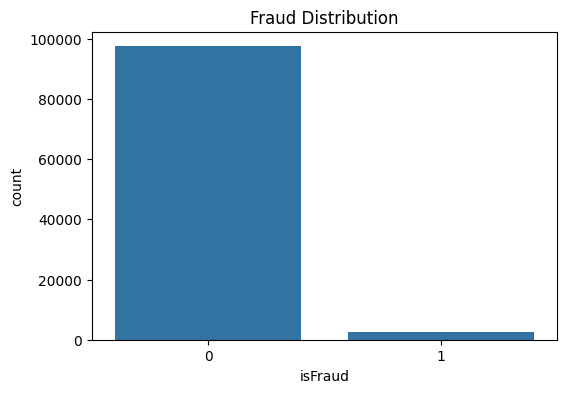

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud",data=train)

plt.title("Fraud Distribution")

plt.show()

In [ ]:
print("Rows :", train.shape[0])
print("Columns :", train.shape[1])

Rows : 100000
Columns : 422


In [ ]:
train.dtypes.value_counts()

,count
float32,389
object,29
int32,2
int8,1
int16,1


In [ ]:
print("Memory Usage (MB):")
print(train.memory_usage().sum()/1024**2)

Memory Usage (MB):
171.56613540649414


In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,100000.0,3.037000e+06,28867.657797,2987000.000,3011999.75,3036999.5,3.061999e+06,3.086999e+06
isFraud,100000.0,2.561000e-02,0.157970,0.000,0.00,0.0,0.000000e+00,1.000000e+00
TransactionDT,100000.0,1.135124e+06,573348.379339,86400.000,653748.75,1189342.5,1.643471e+06,2.006364e+06
TransactionAmt,100000.0,1.307433e+02,206.019913,0.292,45.00,75.0,1.359500e+02,4.829950e+03
card1,100000.0,9.878399e+03,4933.563070,1001.000,6019.00,9653.0,1.429000e+04,1.839500e+04
...,...,...,...,...,...,...,...,...
id_17,39880.0,1.782180e+02,25.659029,100.000,166.00,166.0,1.660000e+02,2.290000e+02
id_18,12981.0,1.397820e+01,1.479599,11.000,13.00,13.0,1.500000e+01,2.900000e+01
id_19,39871.0,3.625501e+02,146.486420,100.000,266.00,352.0,4.920000e+02,6.710000e+02
id_20,39866.0,3.833880e+02,155.161163,100.000,222.00,391.0,5.210000e+02,6.600000e+02


In [ ]:
numerical_cols = train.select_dtypes(include=np.number).columns

categorical_cols = train.select_dtypes(include="object").columns

print("Numerical Features :", len(numerical_cols))
print("Categorical Features :", len(categorical_cols))

Numerical Features : 393
Categorical Features : 29


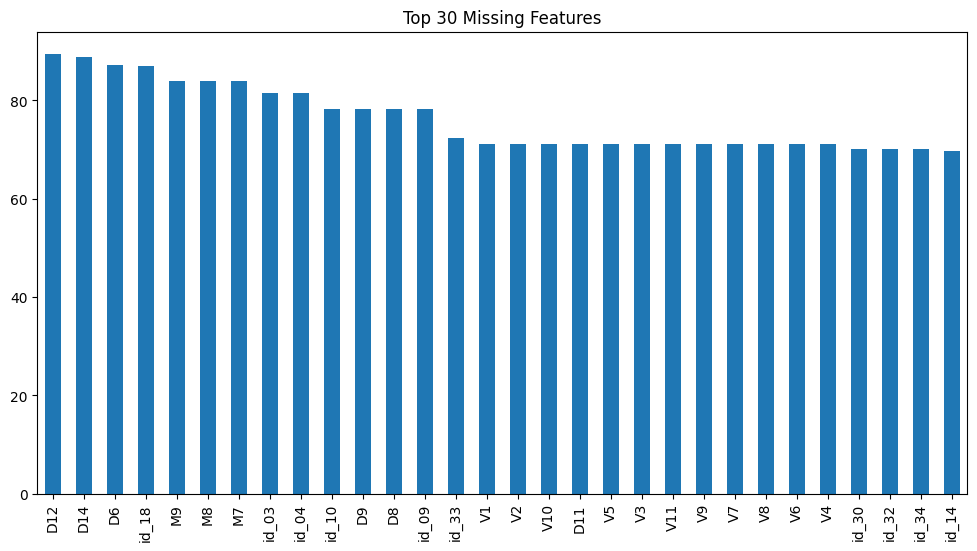

In [ ]:
missing = train.isnull().mean()*100

missing = missing.sort_values(ascending=False)

plt.figure(figsize=(12,6))

missing.head(30).plot(kind="bar")

plt.title("Top 30 Missing Features")

plt.show()

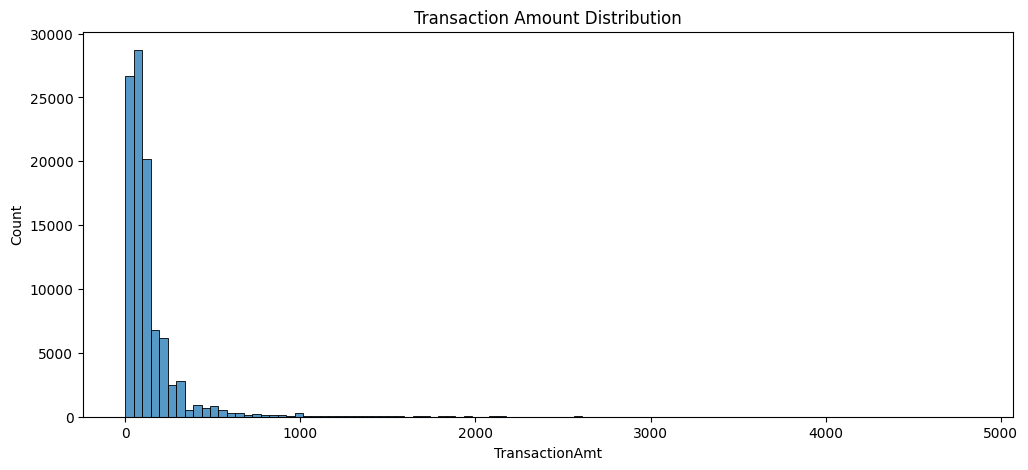

In [ ]:
plt.figure(figsize=(12,5))

sns.histplot(train["TransactionAmt"],bins=100)

plt.title("Transaction Amount Distribution")

plt.show()

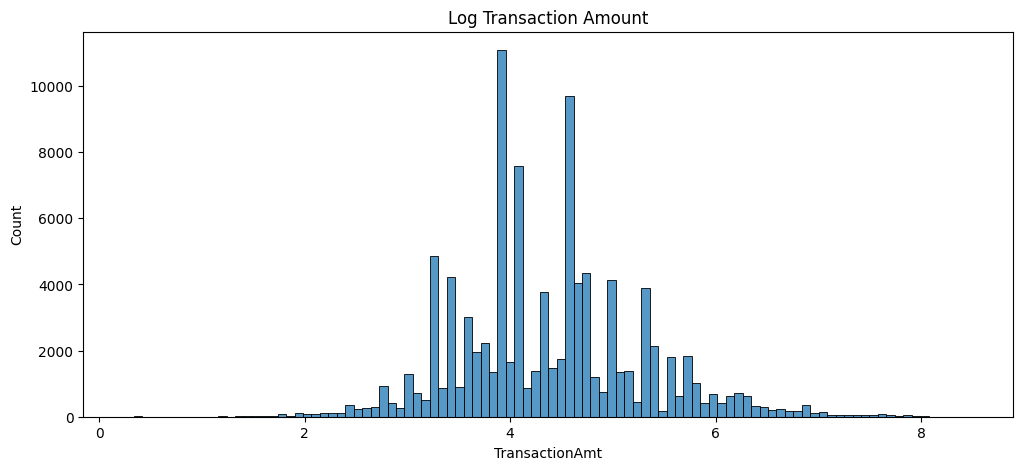

In [ ]:
plt.figure(figsize=(12,5))

sns.histplot(np.log1p(train["TransactionAmt"]),bins=100)

plt.title("Log Transaction Amount")

plt.show()

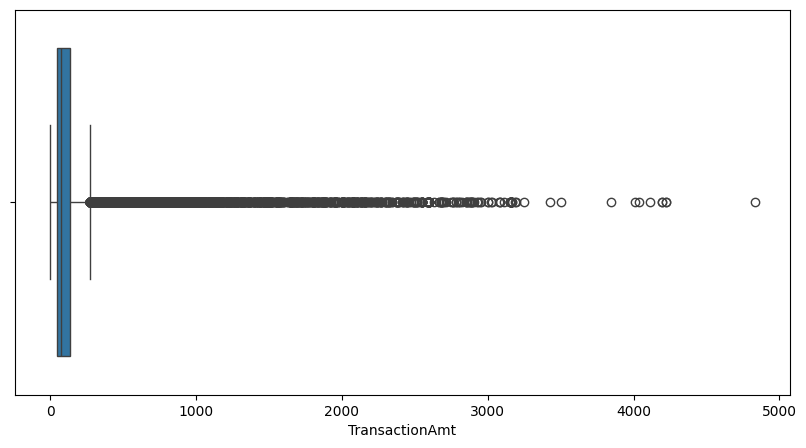

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x=train["TransactionAmt"])

plt.show()

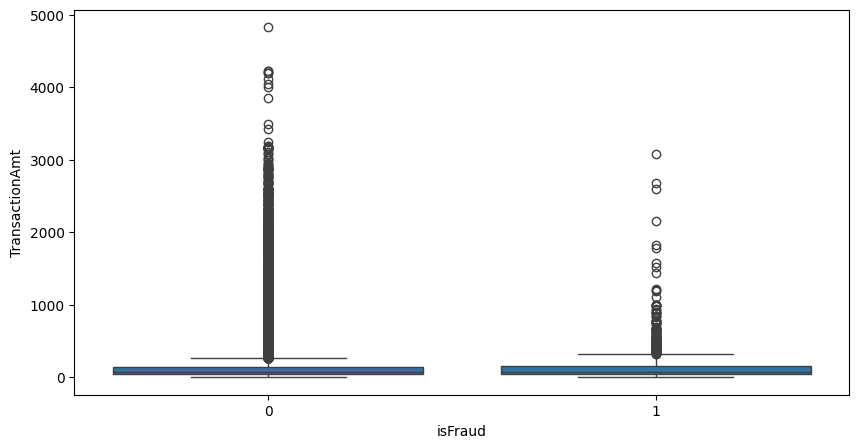

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=train,
    x="isFraud",
    y="TransactionAmt"
)

plt.show()

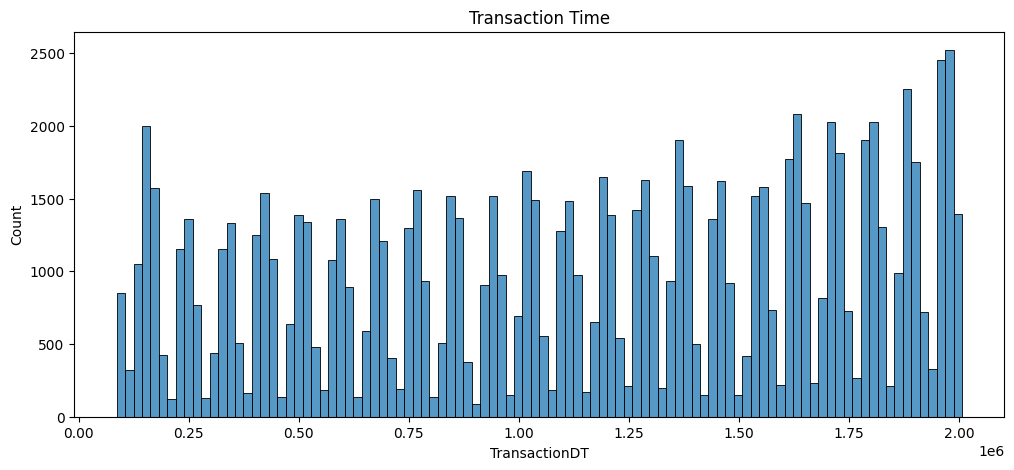

In [ ]:
plt.figure(figsize=(12,5))

sns.histplot(train["TransactionDT"],bins=100)

plt.title("Transaction Time")

plt.show()

In [ ]:
train["Hour"] = (train["TransactionDT"]//3600)%24

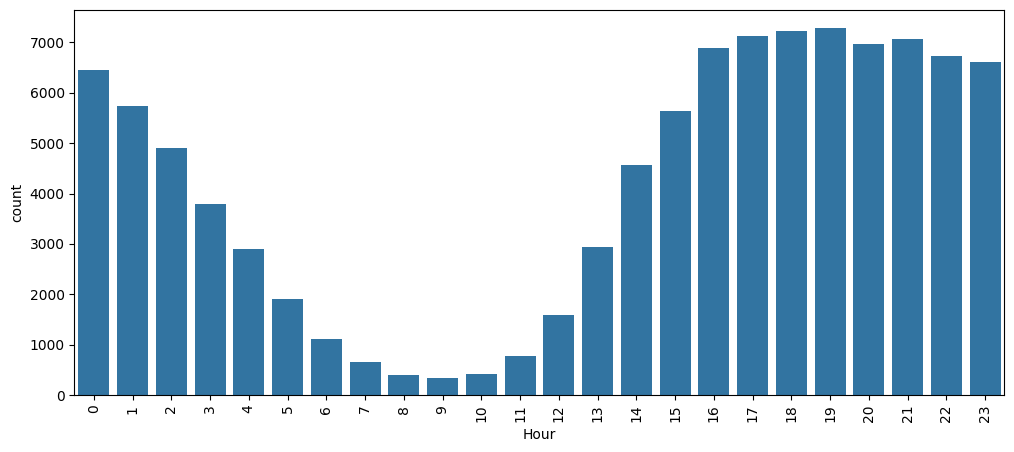

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(x=train["Hour"])

plt.xticks(rotation=90)

plt.show()

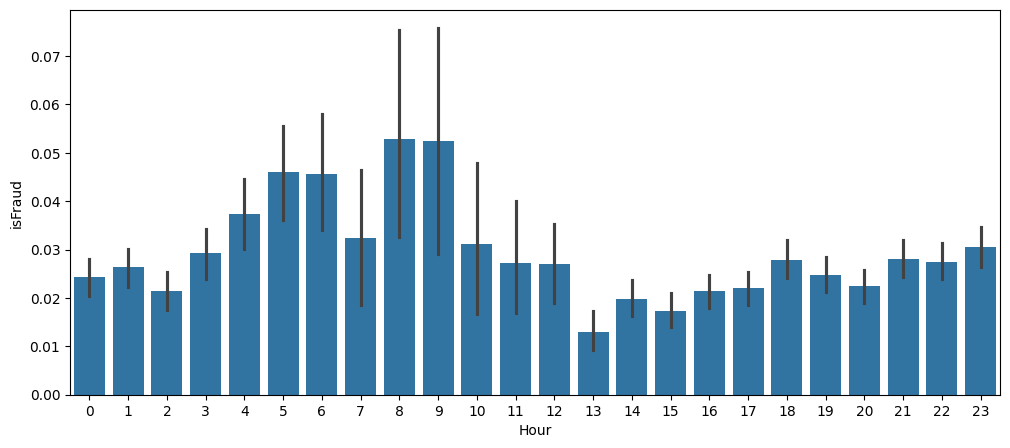

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=train,
    x="Hour",
    y="isFraud"
)

plt.show()

In [ ]:
train["Day"] = (train["TransactionDT"]//86400)%7

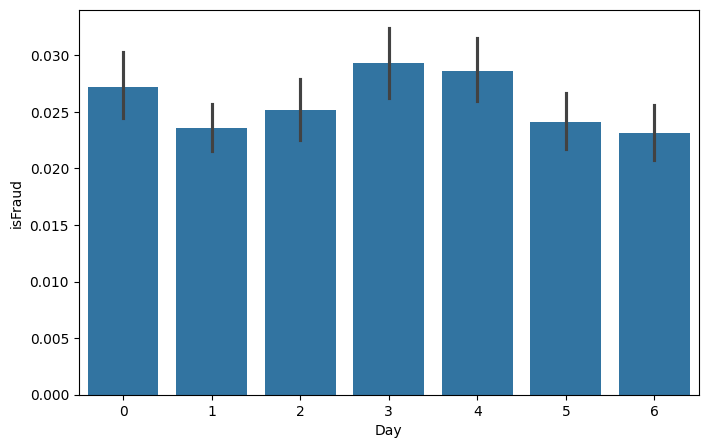

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=train,
    x="Day",
    y="isFraud"
)

plt.show()

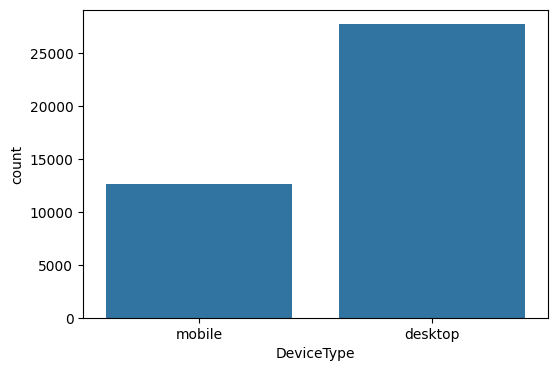

In [ ]:
if "DeviceType" in train.columns:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=train,
        x="DeviceType"
    )

    plt.show()

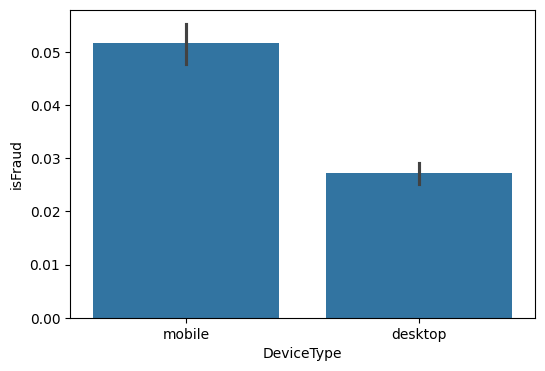

In [ ]:
if "DeviceType" in train.columns:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=train,
        x="DeviceType",
        y="isFraud"
    )

    plt.show()

In [ ]:
corr = train.corr(numeric_only=True)["isFraud"].sort_values()

corr.tail(20)

,isFraud
V155,0.210177
V198,0.214386
V233,0.214697
V242,0.215373
V87,0.218523
V244,0.232292
V171,0.232347
V158,0.232770
V44,0.234892
V149,0.238343


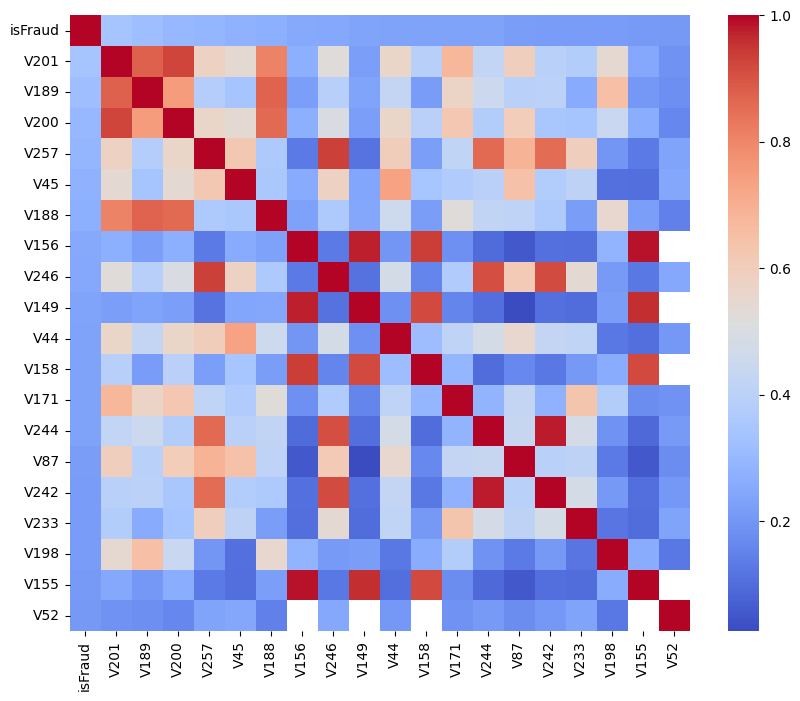

In [ ]:
top_features = corr.abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(10,8))

sns.heatmap(
    train[top_features].corr(),
    cmap="coolwarm"
)

plt.show()

In [ ]:
train["Amount_Category"] = pd.qcut(
    train["TransactionAmt"],
    q=10,
    duplicates="drop"
)

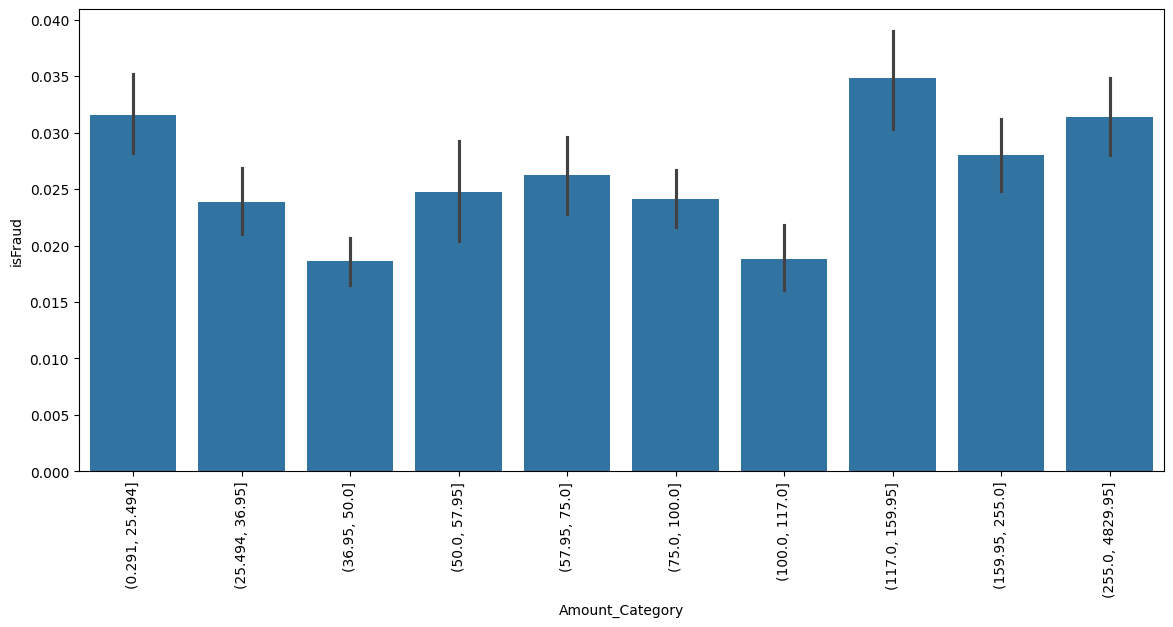

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=train,
    x="Amount_Category",
    y="isFraud"
)

plt.xticks(rotation=90)

plt.show()

In [ ]:
train.to_csv(
    "clean_train.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
train = pd.read_csv("clean_train.csv")

print(train.shape)

(100000, 425)


In [ ]:
train["TransactionAmt_Log"] = np.log1p(train["TransactionAmt"])

In [ ]:
train["TransactionAmt_Square"] = train["TransactionAmt"] ** 2

In [ ]:
train["TransactionAmt_CubeRoot"] = np.cbrt(train["TransactionAmt"])

In [ ]:
train["TransactionAmt_Rank"] = train["TransactionAmt"].rank()

In [ ]:
train["TransactionAmt_Percentile"] = train["TransactionAmt"].rank(pct=True)

In [ ]:
mean_amt = train["TransactionAmt"].mean()
std_amt = train["TransactionAmt"].std()

train["TransactionAmt_ZScore"] = (
    train["TransactionAmt"] - mean_amt
) / std_amt

In [ ]:
train["Missing_Count"] = train.isnull().sum(axis=1)

In [ ]:
train["Missing_Percentage"] = (
    train.isnull().mean(axis=1) * 100
)

In [ ]:
print(train.duplicated().sum())

0


In [ ]:
train.drop_duplicates(inplace=True)

print(train.shape)

(100000, 433)


In [ ]:
X = train.drop("isFraud", axis=1)

y = train["isFraud"]

In [ ]:
cat_cols = X.select_dtypes(include="object").columns

print(cat_cols)

print(len(cat_cols))

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35',
       'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo',
       'Amount_Category'],
      dtype='object')
30


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    X[col] = X[col].astype(str)

    X[col] = le.fit_transform(X[col])

    encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [ ]:
X = X.fillna(-999)

In [ ]:
constant_cols = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print(len(constant_cols))

X.drop(columns=constant_cols, inplace=True)

1


In [ ]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.98)
]

print(len(to_drop))

X.drop(columns=to_drop, inplace=True)

253


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
14,C1,0.033386
3,card1,0.029846
0,TransactionID,0.029512
19,C13,0.024415
4,card2,0.022226
9,addr1,0.020853
174,TransactionAmt_Square,0.019404
1,TransactionAmt,0.019253
176,TransactionAmt_Rank,0.019238
175,TransactionAmt_CubeRoot,0.018739


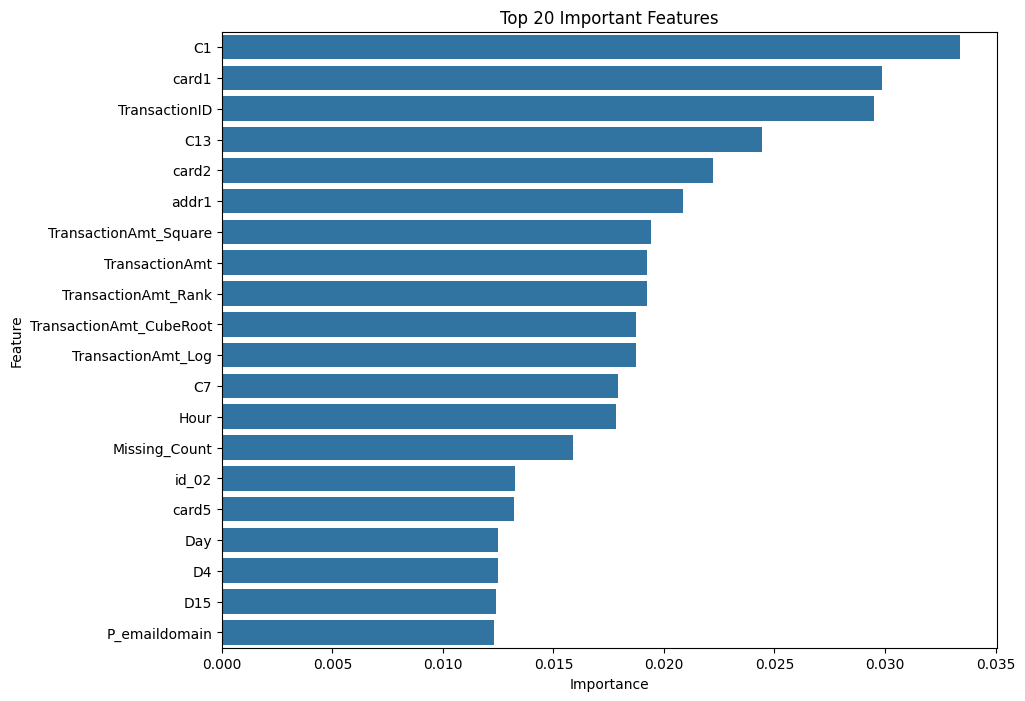

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (80000, 178)
Testing Shape : (20000, 178)


In [ ]:
!pip install -q imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(155902, 178)
isFraud
0    77951
1    77951
Name: count, dtype: int64


In [ ]:
results = {}

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_smote, y_train_smote)

pred_lr = lr.predict(X_test)

prob_lr = lr.predict_proba(X_test)[:,1]

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

pred_rf = rf.predict(X_test)

prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

pred_xgb = xgb.predict(X_test)

prob_xgb = xgb.predict_proba(X_test)[:,1]

In [ ]:
lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb.fit(
    X_train_smote,
    y_train_smote
)

pred_lgb = lgb.predict(X_test)

prob_lgb = lgb.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 77951, number of negative: 77951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.260475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38121
[LightGBM] [Info] Number of data points in the train set: 155902, number of used features: 178
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [ ]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    verbose=False,
    random_state=42
)

cat.fit(
    X_train_smote,
    y_train_smote
)

pred_cat = cat.predict(X_test)

prob_cat = cat.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, pred, prob):

    results[name] = [

        accuracy_score(y_true,pred),

        precision_score(y_true,pred),

        recall_score(y_true,pred),

        f1_score(y_true,pred),

        roc_auc_score(y_true,prob)

    ]

In [ ]:
evaluate_model(
    "Logistic Regression",
    y_test,
    pred_lr,
    prob_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    pred_rf,
    prob_rf
)

evaluate_model(
    "XGBoost",
    y_test,
    pred_xgb,
    prob_xgb
)

evaluate_model(
    "LightGBM",
    y_test,
    pred_lgb,
    prob_lgb
)

evaluate_model(
    "CatBoost",
    y_test,
    pred_cat,
    prob_cat
)

In [ ]:
comparison = pd.DataFrame(
    results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
).T

comparison

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.78525,0.067459,0.576172,0.120778,0.766781
Random Forest,0.98285,0.896714,0.373047,0.526897,0.889880
XGBoost,0.98465,0.875458,0.466797,0.608917,0.927310
LightGBM,0.98365,0.849057,0.439453,0.579151,0.914949
CatBoost,0.98155,0.787149,0.382812,0.515112,0.892648


In [ ]:
comparison.sort_values(
    "ROC AUC",
    ascending=False
)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
XGBoost,0.98465,0.875458,0.466797,0.608917,0.927310
LightGBM,0.98365,0.849057,0.439453,0.579151,0.914949
CatBoost,0.98155,0.787149,0.382812,0.515112,0.892648
Random Forest,0.98285,0.896714,0.373047,0.526897,0.889880
Logistic Regression,0.78525,0.067459,0.576172,0.120778,0.766781


In [ ]:
joblib.dump(
    xgb,
    "best_fraud_model.pkl"
)

print("Model Saved")

Model Saved


In [ ]:
from google.colab import files

files.download(
    "best_fraud_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
joblib.dump(
    encoders,
    "label_encoders.pkl"
)

['label_encoders.pkl']

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators":[200,300,500],
    "max_depth":[4,6,8,10],
    "learning_rate":[0.01,0.03,0.05,0.1],
    "subsample":[0.7,0.8,1.0],
    "colsample_bytree":[0.7,0.8,1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote,y_train_smote)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=300, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print(random_search.best_params_)

{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [ ]:
best_model = random_search.best_estimator_

In [ ]:
best_pred = best_model.predict(X_test)

best_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy :",accuracy_score(y_test,best_pred))

print("Precision :",precision_score(y_test,best_pred))

print("Recall :",recall_score(y_test,best_pred))

print("F1 :",f1_score(y_test,best_pred))

print("ROC AUC :",roc_auc_score(y_test,best_prob))

Accuracy : 0.9852
Precision : 0.8913043478260869
Recall : 0.48046875
F1 : 0.6243654822335025
ROC AUC : 0.9360896769807061


In [ ]:
print(classification_report(
    y_test,
    best_pred
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19488
           1       0.89      0.48      0.62       512

    accuracy                           0.99     20000
   macro avg       0.94      0.74      0.81     20000
weighted avg       0.98      0.99      0.98     20000



In [ ]:
cm = confusion_matrix(
    y_test,
    best_pred
)

cm

array([[19458,    30],
       [  266,   246]])

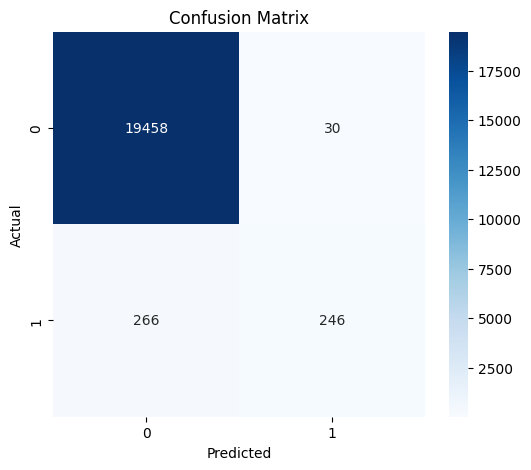

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

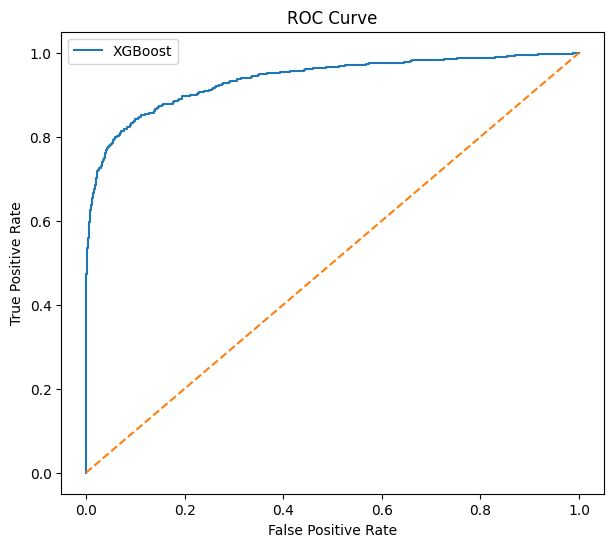

In [ ]:
fpr,tpr,_=roc_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label="XGBoost")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

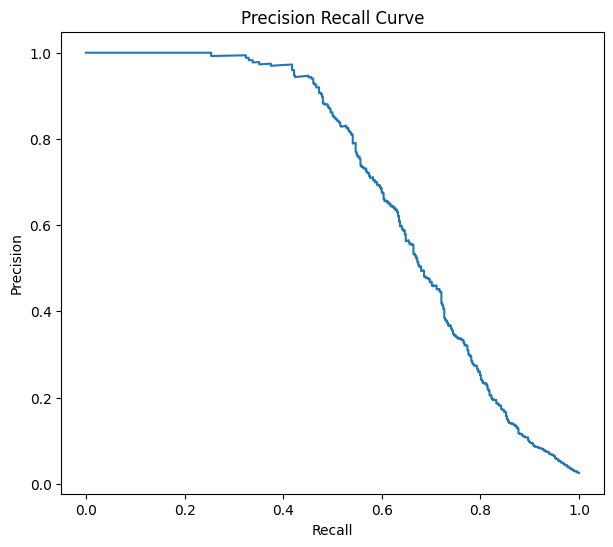

In [ ]:
precision,recall,_=precision_recall_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(7,6))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
16,C5,0.072495
142,V317,0.059427
114,V274,0.058440
110,V265,0.053400
83,V133,0.043880
14,C1,0.043286
36,M4,0.043267
143,V318,0.038777
122,V282,0.030976
127,V294,0.025358


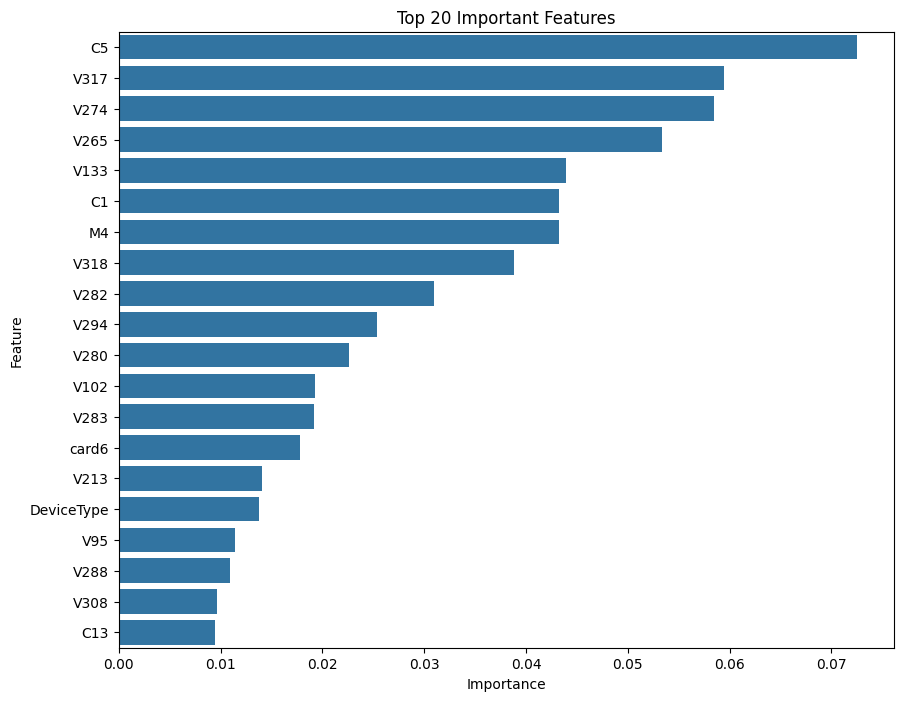

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

In [ ]:
explainer = shap.TreeExplainer(best_model)

In [ ]:
sample = X_test.sample(
    1000,
    random_state=42
)

shap_values = explainer.shap_values(sample)

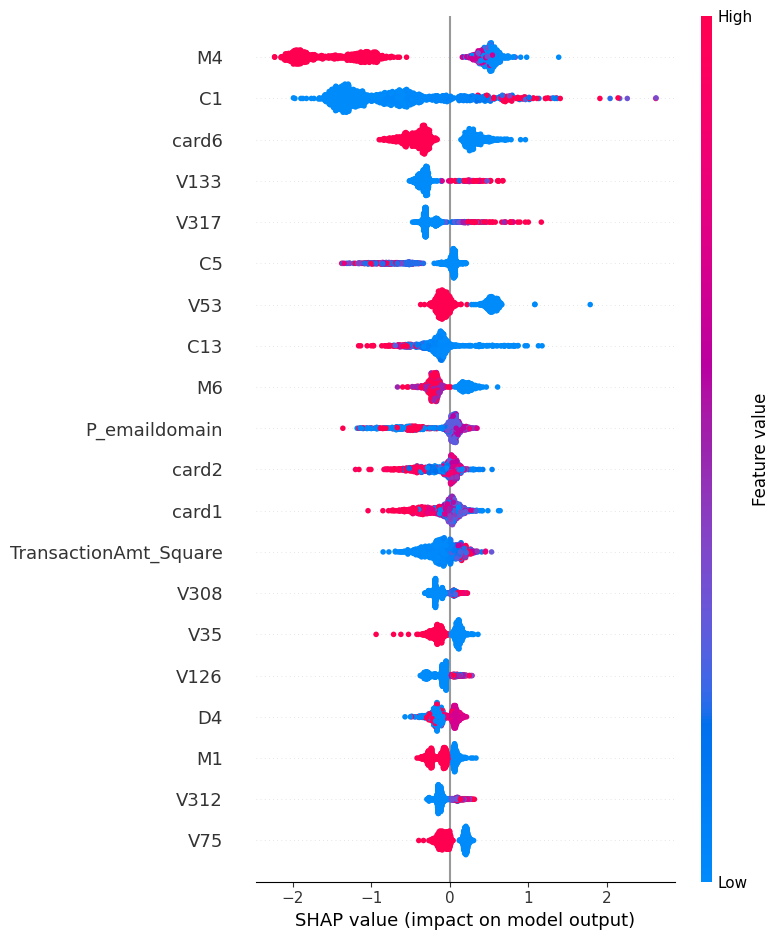

In [ ]:
shap.summary_plot(
    shap_values,
    sample
)

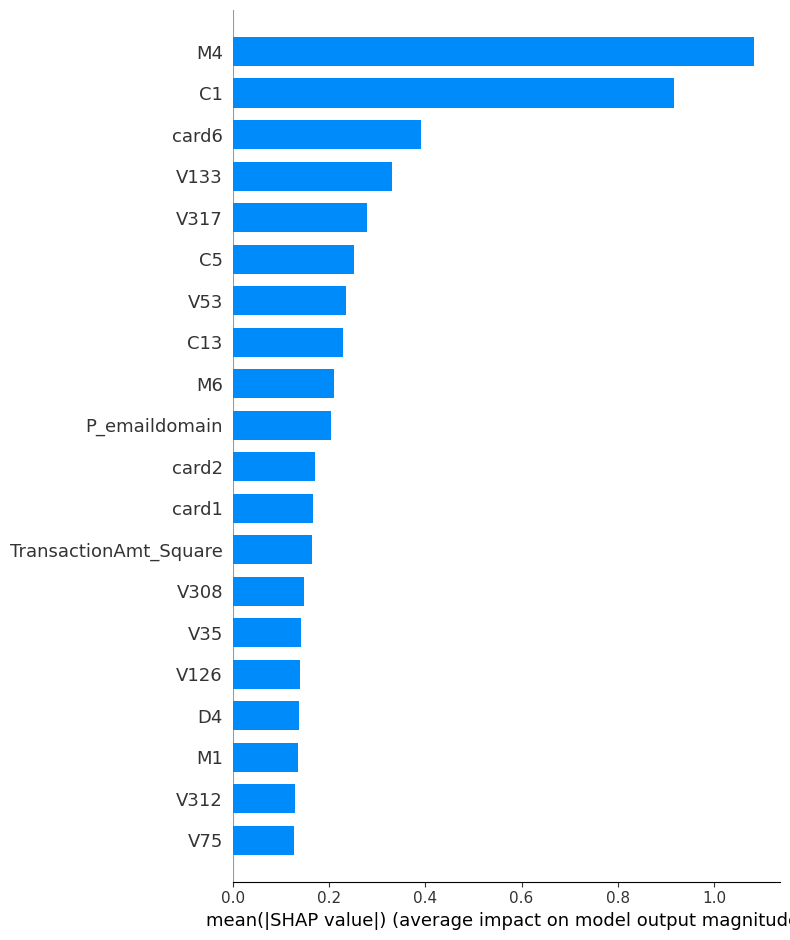

In [ ]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

In [ ]:
joblib.dump(
    best_model,
    "IEEE_Fraud_Model.pkl"
)

['IEEE_Fraud_Model.pkl']

In [ ]:
joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [ ]:
joblib.dump(
    encoders,
    "encoders.pkl"
)

['encoders.pkl']

In [ ]:
loaded = joblib.load(
    "IEEE_Fraud_Model.pkl"
)

print(type(loaded))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
sample = X_test.iloc[[0]]

prediction = loaded.predict(sample)

prediction

array([0])

In [ ]:
loaded.predict_proba(sample)

array([[0.9988081 , 0.00119189]], dtype=float32)

In [ ]:
from google.colab import files

files.download("IEEE_Fraud_Model.pkl")

files.download("encoders.pkl")

files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(best_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print("✔ Data Cleaning")
print("✔ EDA")
print("✔ Feature Engineering")
print("✔ Feature Selection")
print("✔ Random Forest")
print("✔ XGBoost")
print("✔ LightGBM")
print("✔ CatBoost")
print("✔ Hyperparameter Tuning")
print("✔ SHAP Explainability")
print("✔ Model Saved")
print("="*60)

PROJECT COMPLETED SUCCESSFULLY
✔ Data Cleaning
✔ EDA
✔ Feature Engineering
✔ Feature Selection
✔ Random Forest
✔ XGBoost
✔ LightGBM
✔ CatBoost
✔ Hyperparameter Tuning
✔ SHAP Explainability
✔ Model Saved


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 78.8 MB/s eta 0:00:00


In [ ]:
joblib.dump(best_model,"IEEE_Fraud_Model.pkl")
joblib.dump(encoders,"encoders.pkl")
joblib.dump(X.columns.tolist(),"feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
from google.colab import files

files.download("IEEE_Fraud_Model.pkl")
files.download("encoders.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

os.listdir()

['.config',
 'IEEE_Fraud_Model.pkl',
 'feature_columns.pkl',
 'catboost_info',
 'clean_train.csv',
 'label_encoders.pkl',
 'encoders.pkl',
 'best_fraud_model.pkl',
 'ieee-fraud-detection (1).zip',
 'dataset',
 'ieee-fraud-detection (2).zip',
 'ieee-fraud-detection (3).zip',
 'ieee-fraud-detection.zip',
 'Fraud_Detection_Model.pkl',
 'sample_data']

In [ ]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("feature_columns.pkl saved successfully!")

feature_columns.pkl saved successfully!


In [ ]:
from google.colab import files

files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>